# FASTQ Exploration and Nucleotide Composition

Analysis of paired-end Illumina WGS data from *Escherichia coli*.

**SRA accession:** SRR31439393  
**File analyzed:** SRR31439393_1.fastq  
**Tools:** Python, Biopython

## 1. Inspecting a FASTQ Record

First, we inspect a single FASTQ record to examine how Biopython
represents sequence identifiers, descriptions, nucleotide sequences,
and per-base Phred quality scores.

In [5]:
from Bio import SeqIO

recs = SeqIO.parse("/home/elena/SRR31439393/SRR31439393_1.fastq", "fastq")

rec = next(recs)

print(rec.id)
print(rec.description)
print(rec.seq)
print(rec.letter_annotations)

SRR31439393.1
SRR31439393.1 VL00114:675:AAG5LFVM5:1:1101:22889:1000 length=99
CCTGATGGGTGTGCTGTTTACGATAATTTCTGCCACGGGTATCCGTAGCTGGATTTTGCGCAACTTGCCGCACGGTGTGGCGCACGGCACGGGGATCGG
{'phred_quality': [34, 34, 34, 34, 34, 34, 34, 12, 34, 34, 34, 34, 34, 12, 34, 34, 34, 34, 26, 34, 26, 34, 34, 34, 34, 34, 26, 12, 34, 34, 12, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 26, 34, 34, 34, 34, 26, 34, 34, 26, 26, 34, 34, 26, 34, 34, 34, 34, 34, 34, 12, 34, 34, 12, 34, 34, 12, 34, 34, 26, 34, 34, 26, 34, 12, 34, 34, 34, 34, 34, 34, 34, 34, 26, 12, 34, 26, 26, 12, 34, 26, 34, 34, 34, 34, 34, 34]}


## 2. Nucleotide Composition

The nucleotide composition of the R1 FASTQ file was calculated by
iterating through all reads and counting each nucleotide.

The FASTQ file was processed sequentially using `SeqIO.parse()`,
without loading the complete dataset into memory.

In [6]:

from collections import defaultdict
recs = SeqIO.parse("/home/elena/SRR31439393/SRR31439393_1.fastq", "fastq")
cnt = defaultdict(int)
for rec in recs:
    for letter in rec.seq:
        cnt[letter] += 1
tot = sum(cnt.values())

for letter, count in cnt.items():
    print(f"{letter}: {100 * count / tot:.2f}% ({count})")

C: 25.44% (32256342)
T: 24.31% (30822345)
G: 25.70% (32581456)
A: 24.38% (30915901)
N: 0.17% (210491)


## 3. Distribution of N Calls by Read Position

The overall nucleotide composition showed that 0.17% of the
observed bases were reported as `N`. To investigate whether
ambiguous bases were concentrated at particular positions within
the reads, the number of `N` calls was calculated for each read
position.

The analysis was performed on the R1 FASTQ file using Biopython
`SeqIO.parse()`. Each read was examined base by base, and `N` calls
were counted according to their position within the read.

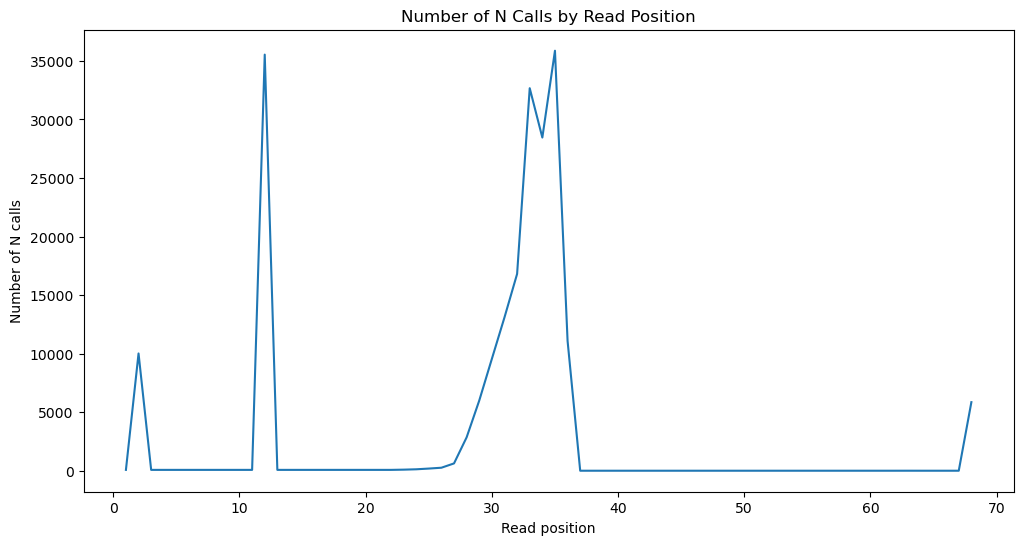

In [7]:
from collections import defaultdict
from Bio import SeqIO
import matplotlib.pyplot as plt

recs = SeqIO.parse(
    "/home/elena/SRR31439393/SRR31439393_1.fastq",
    "fastq"
)

n_cnt = defaultdict(int)

for rec in recs:
    for i, letter in enumerate(rec.seq):
        pos = i + 1
        if letter == "N":
            n_cnt[pos] += 1

seq_len = max(n_cnt.keys())
positions = range(1, seq_len + 1)

plt.figure(figsize=(12, 6))
plt.plot(positions, [n_cnt[x] for x in positions])

plt.title("Number of N Calls by Read Position")
plt.xlabel("Read position")
plt.ylabel("Number of N calls")

plt.show()

In [5]:
for position, count in sorted(n_cnt.items()):
    print(position, count)

1 72
2 10014
3 72
4 72
5 72
6 72
7 72
8 72
9 72
10 72
11 72
12 35534
13 72
14 72
15 72
16 72
17 72
18 72
19 72
20 72
21 72
22 72
23 91
24 122
25 184
26 256
27 624
28 2852
29 5993
30 9554
31 13096
32 16808
33 32665
34 28452
35 35867
36 11082
37 0
38 0
39 0
40 0
41 0
42 0
43 0
44 0
45 0
46 0
47 0
48 0
49 0
50 0
51 0
52 0
53 0
54 0
55 0
56 0
57 0
58 0
59 0
60 0
61 0
62 0
63 1
64 0
65 0
66 0
67 0
68 5856


In [8]:
sum(n_cnt.values())

210491

### Results

A total of 210,491 `N` calls were detected, corresponding to
0.17% of all analyzed bases.

The `N` calls were not uniformly distributed across read positions.
Several pronounced peaks were observed, particularly at positions
2, 12, and 28–36, with an additional peak at position 68.

The highest number of `N` calls was observed at position 35,
with 35,867 calls.


## 4. Read Length Distribution

The length of each read in the R1 FASTQ file was calculated using
Biopython. The distribution of read lengths was examined to
characterize the sequencing dataset and assess read-length
consistency.

In [7]:
from Bio import SeqIO

recs = SeqIO.parse(
    "/home/elena/SRR31439393/SRR31439393_1.fastq",
    "fastq"
)

read_lengths = []

for rec in recs:
    read_lengths.append(len(rec.seq))

In [8]:
print("Number of reads:", len(read_lengths))
print("Minimum read length:", min(read_lengths))
print("Maximum read length:", max(read_lengths))
print("Mean read length:", sum(read_lengths) / len(read_lengths))

Number of reads: 1457207
Minimum read length: 35
Maximum read length: 99
Mean read length: 87.00653716321703


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(read_lengths, bins=range(35, 101), edgecolor="black")

plt.title("Read Length Distribution")
plt.xlabel("Read length (bp)")
plt.ylabel("Number of reads")

plt.show()

### Results

The R1 FASTQ file contains 1,457,207 reads with lengths ranging
from 35 to 99 bp. The mean read length is 87.01 bp.

The read length distribution is strongly concentrated at 99 bp,
with a smaller peak at 98 bp and additional groups of shorter reads.
A small but distinct group of reads has a length of 35 bp.

The predominance of 99 bp reads indicates that the dataset is
largely composed of near-full-length reads, while the presence of
shorter reads indicates heterogeneity in read length.

The shorter reads were retained because the available QC results did
not provide sufficient evidence that length-based filtering was required.

## 5. Phred Quality Score Distribution

The distribution of Phred quality scores was analyzed for all bases
in the R1 FASTQ file.

For each read, the per-base Phred quality scores were extracted from
the `SeqRecord` object using Biopython. The frequency of each quality
score was then calculated across the dataset.

This analysis provides an overview of the sequencing quality before
examining how quality changes across individual read positions.

In [10]:
from collections import defaultdict
from Bio import SeqIO

recs = SeqIO.parse(
    "/home/elena/SRR31439393/SRR31439393_1.fastq",
    "fastq"
)

cnt_qual = defaultdict(int)

for rec in recs:
    for qual in rec.letter_annotations["phred_quality"]:
        cnt_qual[qual] += 1

tot = sum(cnt_qual.values())

for qual, count in sorted(cnt_qual.items()):
    print(f"{qual}: {100 * count / tot:.2f}% ({count})")

2: 0.17% (210491)
12: 5.03% (6371630)
26: 5.96% (7560859)
34: 88.85% (112643555)


### Results

The R1 FASTQ file contained four distinct Phred quality scores:
Q2, Q12, Q26, and Q34.

The majority of bases (88.85%) had a Phred score of 34, indicating
high base-call quality for most of the dataset. Q26 accounted for
5.96% of bases, while Q12 accounted for 5.03%.

A total of 210,491 bases had a Phred score of 2. This number exactly
matches the total number of `N` bases identified in the nucleotide
composition analysis, indicating that all `N` calls in this dataset
were assigned a Phred score of 2.

The quality-score distribution therefore shows that most bases were
called with high confidence, while a smaller fraction had lower
quality scores or were reported as ambiguous `N` bases.

## 6. Per-base Phred Quality

To investigate how sequencing quality varies across read positions,
the distribution of Phred quality scores was calculated separately
for each position in the R1 reads.

Unlike the previous analysis, which examined the overall frequency
of Phred scores, this analysis preserves the positional information
and allows changes in quality across the read to be visualized.



In [13]:
from collections import defaultdict
from Bio import SeqIO

recs = SeqIO.parse(
    "/home/elena/SRR31439393/SRR31439393_1.fastq",
    "fastq"
)

qual_pos = defaultdict(list)

for rec in recs:
    for i, qual in enumerate(rec.letter_annotations["phred_quality"]):
        pos = i + 1
        qual_pos[pos].append(qual)

In [18]:
from collections import Counter

for pos, n_count in top_n_positions:
    quality_counts = Counter(qual_pos[pos])

    print(f"\nPosition {pos}: N calls = {n_count}")

    for qual in sorted(quality_counts):
        count = quality_counts[qual]
        percentage = 100 * count / len(qual_pos[pos])

        print(f"  Q{qual}: {count} ({percentage:.2f}%)")
        


Position 35: N calls = 35867
  Q2: 35867 (2.46%)
  Q12: 64921 (4.46%)
  Q26: 77825 (5.34%)
  Q34: 1278594 (87.74%)

Position 12: N calls = 35534
  Q2: 35534 (2.44%)
  Q12: 80467 (5.52%)
  Q26: 91096 (6.25%)
  Q34: 1250110 (85.79%)

Position 33: N calls = 32665
  Q2: 32665 (2.24%)
  Q12: 64950 (4.46%)
  Q26: 78858 (5.41%)
  Q34: 1280734 (87.89%)

Position 34: N calls = 28452
  Q2: 28452 (1.95%)
  Q12: 65335 (4.48%)
  Q26: 78309 (5.37%)
  Q34: 1285111 (88.19%)

Position 32: N calls = 16808
  Q2: 16808 (1.15%)
  Q12: 66046 (4.53%)
  Q26: 78858 (5.41%)
  Q34: 1295495 (88.90%)

Position 31: N calls = 13096
  Q2: 13096 (0.90%)
  Q12: 65668 (4.51%)
  Q26: 79448 (5.45%)
  Q34: 1298995 (89.14%)

Position 36: N calls = 11082
  Q2: 11082 (0.78%)
  Q12: 65058 (4.60%)
  Q26: 77958 (5.51%)
  Q34: 1259952 (89.10%)

Position 2: N calls = 10014
  Q2: 10014 (0.69%)
  Q12: 79355 (5.45%)
  Q26: 100021 (6.86%)
  Q34: 1267817 (87.00%)

Position 30: N calls = 9554
  Q2: 9554 (0.66%)
  Q12: 65098 (4.47%)
  Q

### Results

The analysis of Phred quality scores at positions with the highest
number of `N` calls showed that all `N` bases were assigned a Phred
score of 2 (Q2), the lowest quality score observed in the dataset.

However, `N` calls represented only a small fraction of all bases
at the affected positions. For example, at position 35, which had
the highest number of `N` calls, 2.46% of bases had Q2, while 87.74%
had Q34.

These results indicate that the positional peaks of `N` calls are
associated with very low-quality base calls, but the affected
positions are not globally low-quality because the majority of bases
at these positions have high Phred scores.

## 7. GC Content

In [21]:
gc_content = 100 * (cnt["G"] + cnt["C"]) / (
    cnt["A"] + cnt["C"] + cnt["G"] + cnt["T"]
)

print(f"GC content: {gc_content:.2f}%")

GC content: 51.22%


### Results

The GC content calculated from the R1 FASTQ data was 51.22%,
excluding ambiguous `N` bases.

This value is close to the GC content reported in the SRA metadata
(50.9%), with a difference of only 0.32 percentage points. The
agreement between the two values supports the consistency of the
nucleotide composition analysis.

## Paired-end Read Validation

The R1 and R2 FASTQ files were processed simultaneously using Python's
`zip()` function.

A total of 1,457,207 read pairs were checked. The read identifiers were
identical between R1 and R2 for all checked pairs, with zero mismatches.

This confirms that the R1 and R2 FASTQ files are correctly paired and
maintain consistent read order.

In [14]:
from Bio import SeqIO

f1 = open('/home/elena/SRR31439393/SRR31439393_1.fastq', 'r')
f2 = open('/home/elena/SRR31439393/SRR31439393_2.fastq', 'r')

rec1 = next(SeqIO.parse(f1, 'fastq'))
rec2 = next(SeqIO.parse(f2, 'fastq'))

print("R1 ID:", rec1.id)
print("R2 ID:", rec2.id)

f1.close()
f2.close()

R1 ID: SRR31439393.1
R2 ID: SRR31439393.1


In [15]:
from Bio import SeqIO

f1 = open('/home/elena/SRR31439393/SRR31439393_1.fastq', 'r')
f2 = open('/home/elena/SRR31439393/SRR31439393_2.fastq', 'r')

recs1 = SeqIO.parse(f1, 'fastq')
recs2 = SeqIO.parse(f2, 'fastq')

pairs_checked = 0
mismatches = 0

for rec1, rec2 in zip(recs1, recs2):
    pairs_checked += 1
    
    if rec1.id != rec2.id:
        mismatches += 1
        print("Mismatch:", rec1.id, rec2.id)
        break

print("Pairs checked:", pairs_checked)
print("Mismatches:", mismatches)

f1.close()
f2.close()

Pairs checked: 1457207
Mismatches: 0
